Trovati 60 samples
Shape: (128, 313)
Classi: Counter({'sheep': 10, 'dog': 9, 'pig': 7, 'crow': 6, 'insects': 5, 'rooster': 4, 'frog': 4, 'chirping_birds': 4, 'crickets': 3, 'cat': 3, 'hen': 3, 'cow': 2})


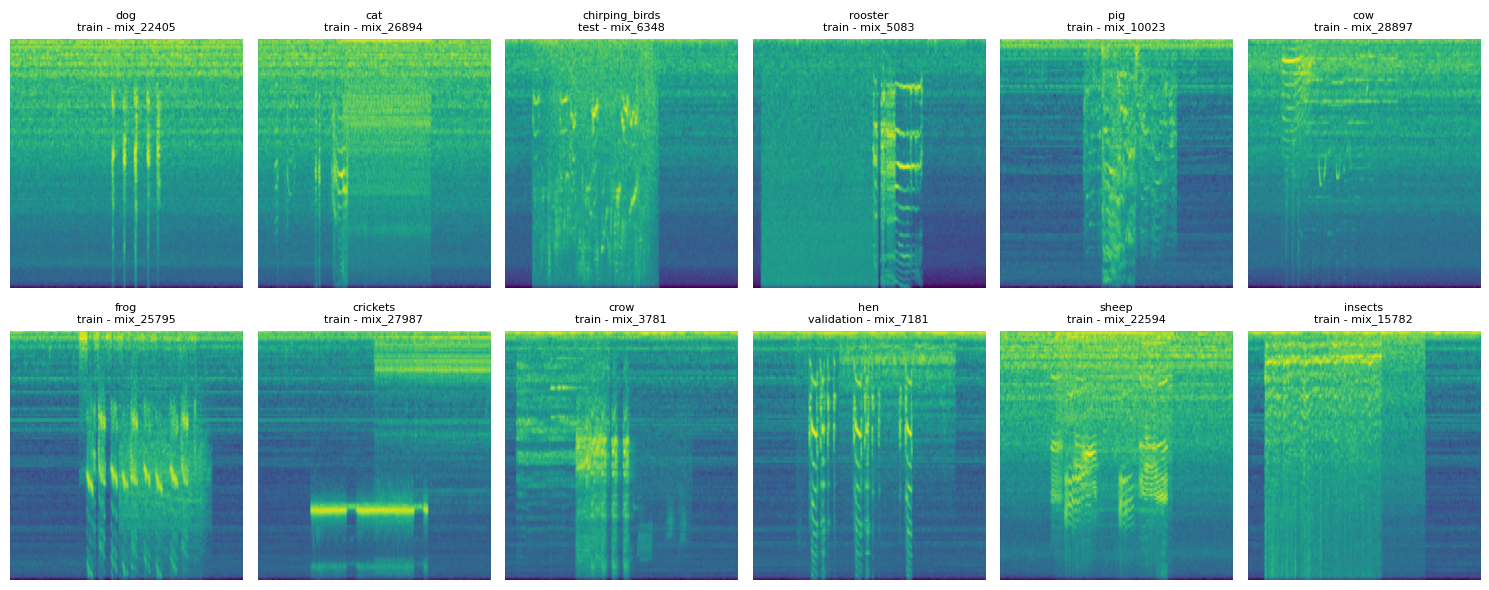

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import Counter

BASE_PATH = "/media/neurone-pc5/Volume/AI & ML/Soundscapes/audio_sources/spettrogrammi"
ANIMALS = ['dog', 'cat', 'chirping_birds', 'rooster', 'pig', 'cow',
           'frog', 'crickets', 'crow', 'hen', 'sheep', 'insects']

def quick_check():
    samples = []
    
    # Carica esempi da train/test/validation
    for split in ['train', 'test', 'validation']:
        split_path = os.path.join(BASE_PATH, split)
        if not os.path.exists(split_path):
            continue
            
        mixes = [f for f in os.listdir(split_path) if f.startswith('mix_')]
        if not mixes:
            continue
            
        for mix in random.sample(mixes, min(20, len(mixes))):  # campiona max 20 per split
            try:
                spec = np.load(os.path.join(split_path, mix, "spectrogram.npz"))['spectrogram']
                label = np.load(os.path.join(split_path, mix, "labels.npz"))['class_name']
                label = label.item() if hasattr(label, "item") else str(label)
                samples.append((spec, label, split, mix))
            except Exception as e:
                print(f"Errore su {mix}: {e}")
    
    if not samples:
        print("Nessun sample trovato")
        return
    
    # Controllo shape 
    shapes = [spec.shape for spec, _, _, _ in samples]
    unique_shapes = set(shapes)
    
    # Info 
    labels = [label for _, label, _, _ in samples]
    print(f"Trovati {len(samples)} samples")
    print(f"Shape: {list(unique_shapes)[0] if len(unique_shapes) == 1 else f'{len(unique_shapes)} diverse!'}")
    print(f"Classi: {Counter(labels)}")
    
    # Plot 2x6 
    fig, axes = plt.subplots(2, 6, figsize=(15, 6))
    examples = {}
    
    # Raccogli esempi con info split + mix
    for spec, label, split, mix in samples:
        if label in ANIMALS and label not in examples:
            examples[label] = (spec, split, mix)
    
    for i, animal in enumerate(ANIMALS):
        ax = axes[i//6, i%6]
        if animal in examples:
            spec, split, mix = examples[animal]
            ax.imshow(spec, aspect='auto', cmap='viridis')
            ax.set_title(f'{animal}\n{split} - {mix}', fontsize=8)
        else:
            ax.text(0.5, 0.5, f'{animal}\nMissing', ha='center', va='center')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

quick_check()